# ⛏️ Mine Geotechnical AI System
### Piezometer-Driven Slope Stability Classification — 2-Class Pipeline
Creating a nodel to predict if a mine design is safe or not-safe and recommend proper design to support it.

**Dataset:** `mine_piezometer_2class.csv` — 87,840 rows, 240 piezometers, 30 sites


## 📦 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, mean_absolute_error, r2_score, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('⚠️  optuna not installed — run: pip install optuna')

plt.rcParams['figure.dpi'] = 120
FS_THRESHOLD = 1.3
COLORS = {'Safe': '#2ecc71', 'Unsafe': '#e74c3c'}

def fs_to_label(f):
    return 'Safe' if f >= FS_THRESHOLD else 'Unsafe'

print('✅ Ready (no TF/Keras — tabular-only pipeline)')
print(f'   2-class threshold: FS ≥ {FS_THRESHOLD} = Safe')


⚠️  optuna not installed — run: pip install optuna
✅ Ready (no TF/Keras — tabular-only pipeline)
   2-class threshold: FS ≥ 1.3 = Safe


## 📂 2. Load & Inspect

In [ ]:
DATA_PATH = 'mine_piezometer_2class.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['piezometer_id', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Missing sensor values: {df[["pore_water_pressure_kPa","water_level_m"]].isnull().sum().sum():,}')
print()
print('Label distribution (2-class):')
vc = df['stability_label'].value_counts()
for lbl, cnt in vc.items():
    print(f'  {lbl}: {cnt:,}  ({cnt/len(df)*100:.1f}%)')
print()
print('Safety factor stats:')
print(df['safety_factor'].describe().round(3))
print()
pz_cons = df.groupby('piezometer_id')['stability_label'].apply(
    lambda x: x.value_counts(normalize=True).max()
)
print(f'Piezometers with BOTH labels (seasonal transition): {(pz_cons < 1.0).sum()}')
print(f'Piezometers with single label all year:             {(pz_cons == 1.0).sum()}')
df.head()


Shape: (87840, 25)
Missing sensor values: 4,450

Label distribution (2-class):
  Unsafe: 67,568  (76.9%)
  Safe: 20,272  (23.1%)

Safety factor stats:
count    87840.000
mean         0.998
std          0.373
min          0.348
25%          0.660
50%          1.007
75%          1.270
max          2.026
Name: safety_factor, dtype: float64

Piezometers with BOTH labels (seasonal transition): 66
Piezometers with single label all year:             174


,site_id,piezometer_id,date,day_of_year,rock_type,slope_angle_deg,slope_height_m,bench_width_m,bench_angle_deg,overall_slope_angle_deg,...,piezo_depth_m,piezo_easting_m,piezo_northing_m,piezo_elevation_masl,pore_water_pressure_kPa,water_level_m,temperature_C,rainfall_index,safety_factor,stability_label
0,MINE_01,MINE_01_PZ01,2020-01-01,1,Sandstone,42.11,55.62,14.78,73.17,36.28,...,38.03,500411.7,6009699.1,263.29,9.755,38.030,13.85,0.0000,0.6520,Unsafe
1,MINE_01,MINE_01_PZ01,2020-01-02,2,Sandstone,42.11,55.62,14.78,69.03,36.60,...,38.03,500411.7,6009699.1,263.29,12.101,38.030,15.00,0.0000,0.6489,Unsafe
2,MINE_01,MINE_01_PZ01,2020-01-03,3,Sandstone,42.11,55.62,14.78,68.98,36.71,...,38.03,500411.7,6009699.1,263.29,6.267,30.200,13.20,0.2008,0.5882,Unsafe
3,MINE_01,MINE_01_PZ01,2020-01-04,4,Sandstone,42.11,55.62,14.78,73.40,35.99,...,38.03,500411.7,6009699.1,263.29,4.491,21.435,15.09,0.0000,0.6148,Unsafe
4,MINE_01,MINE_01_PZ01,2020-01-05,5,Sandstone,42.11,55.62,14.78,72.63,37.64,...,38.03,500411.7,6009699.1,263.29,5.182,25.076,20.25,0.0000,0.6553,Unsafe


## 🔧 3. Preprocessing & Feature Engineering

**Audit note — rolling features:** rolling windows are grouped by `piezometer_id`
and use only backward-looking data (`min_periods=1`). No lookahead leakage.

**Audit fix — scaler:** scaler is fitted ONLY on train rows after the temporal split.


In [ ]:
# ── Fill sensor gaps ──────────────────────────────────────────────────────────
for col in ['pore_water_pressure_kPa', 'water_level_m']:
    df[col] = df.groupby('piezometer_id')[col].transform(lambda x: x.ffill().bfill())

# ── Temporal features ─────────────────────────────────────────────────────────
df['month']           = df['date'].dt.month
df['quarter']         = df['date'].dt.quarter
df['is_wet_season']   = df['month'].isin([4,5,6,7,8,9]).astype(int)
df['drainage_factor'] = df['drainage_installed'].fillna(0).astype(int)

# ── Rolling statistics (7, 14, 30-day) ───────────────────────────────────────
# AUDIT OK: rolling is purely backward-looking per piezometer; no lookahead.
for win in [7, 14, 30]:
    df[f'pwp_roll{win}'] = df.groupby('piezometer_id')['pore_water_pressure_kPa'].transform(
        lambda x: x.rolling(win, min_periods=1).mean())
    df[f'wl_roll{win}']  = df.groupby('piezometer_id')['water_level_m'].transform(
        lambda x: x.rolling(win, min_periods=1).mean())
    df[f'pwp_std{win}']  = df.groupby('piezometer_id')['pore_water_pressure_kPa'].transform(
        lambda x: x.rolling(win, min_periods=1).std().fillna(0))
    df[f'rain_cum{win}'] = df.groupby('piezometer_id')['rainfall_index'].transform(
        lambda x: x.rolling(win, min_periods=1).sum())

# ── Rate of change ────────────────────────────────────────────────────────────
df['pwp_roc1'] = df.groupby('piezometer_id')['pore_water_pressure_kPa'].transform(
    lambda x: x.diff(1).fillna(0))
df['pwp_roc3'] = df.groupby('piezometer_id')['pore_water_pressure_kPa'].transform(
    lambda x: x.diff(3).fillna(0))
df['wl_roc1']  = df.groupby('piezometer_id')['water_level_m'].transform(
    lambda x: x.diff(1).fillna(0))

# ── Physics-informed features (Bishop simplified) ────────────────────────────
gamma = df['unit_weight_kN_m3'];  H = df['slope_height_m']
a_rad = np.deg2rad(df['slope_angle_deg']); c = df['cohesion_kPa']
phi   = np.deg2rad(df['friction_angle_deg']); U = df['pore_water_pressure_kPa']
denom = gamma * H * np.sin(a_rad) * np.cos(a_rad) + 1e-9

df['fs_proxy']     = ((c + gamma*H*(np.cos(a_rad)**2)*np.tan(phi)) / denom).clip(0.1, 5)
df['fs_proxy_pwp'] = ((c + (gamma*H*(np.cos(a_rad)**2) - U/(H+1e-9))*np.tan(phi)) / denom).clip(0.1, 5)
df['ru_coefficient']       = (U / (gamma*H*(np.cos(a_rad)**2) + 1e-9)).clip(0, 2)
df['bench_ratio']          = df['bench_width_m'] / (df['slope_height_m'] + 1e-9)
df['saturation_proxy']     = (df['water_level_m'] / (df['piezo_depth_m'] + 1e-9)).clip(0, 1)
df['pore_pressure_ratio']  = U / (gamma*H + 1e-9)
df['slope_water_interact'] = df['slope_angle_deg'] * df['water_level_m']

# ── One-hot rock type ─────────────────────────────────────────────────────────
rock_dummies = pd.get_dummies(df['rock_type'], prefix='rock').astype(int)
df = pd.concat([df, rock_dummies], axis=1)

# ── Feature lists ─────────────────────────────────────────────────────────────
TEMPORAL_FEATURES = [
    'pore_water_pressure_kPa', 'water_level_m', 'temperature_C', 'rainfall_index',
    'saturation_proxy', 'pore_pressure_ratio', 'ru_coefficient', 'slope_water_interact',
    'day_of_year', 'month', 'quarter', 'is_wet_season',
    'pwp_roll7', 'pwp_roll14', 'pwp_roll30',
    'pwp_std7',  'pwp_std14',  'pwp_std30',
    'pwp_roc1',  'pwp_roc3',
    'wl_roll7',  'wl_roll14',  'wl_roll30', 'wl_roc1',
    'rain_cum7', 'rain_cum14', 'rain_cum30',
    'fs_proxy',  'fs_proxy_pwp',
]
STATIC_FEATURES = [
    'piezo_depth_m', 'piezo_elevation_masl',
    'slope_angle_deg', 'slope_height_m', 'bench_width_m', 'bench_angle_deg',
    'overall_slope_angle_deg', 'number_of_benches',
    'cohesion_kPa', 'friction_angle_deg', 'unit_weight_kN_m3', 'drainage_factor',
    'bench_ratio',
] + list(rock_dummies.columns)
ALL_FEATURES = TEMPORAL_FEATURES + STATIC_FEATURES

le = LabelEncoder()
y_enc = le.fit_transform(df['stability_label'].values)   # 0=Safe, 1=Unsafe

print('Classes:', dict(zip(le.classes_, le.transform(le.classes_))))
print(f'Temporal features: {len(TEMPORAL_FEATURES)} | Static: {len(STATIC_FEATURES)} | Total: {len(ALL_FEATURES)}')


Classes: {'Safe': np.int64(0), 'Unsafe': np.int64(1)}
Temporal features: 29 | Static: 18 | Total: 47


## 📊 4. EDA — Visualising Realistic Noise

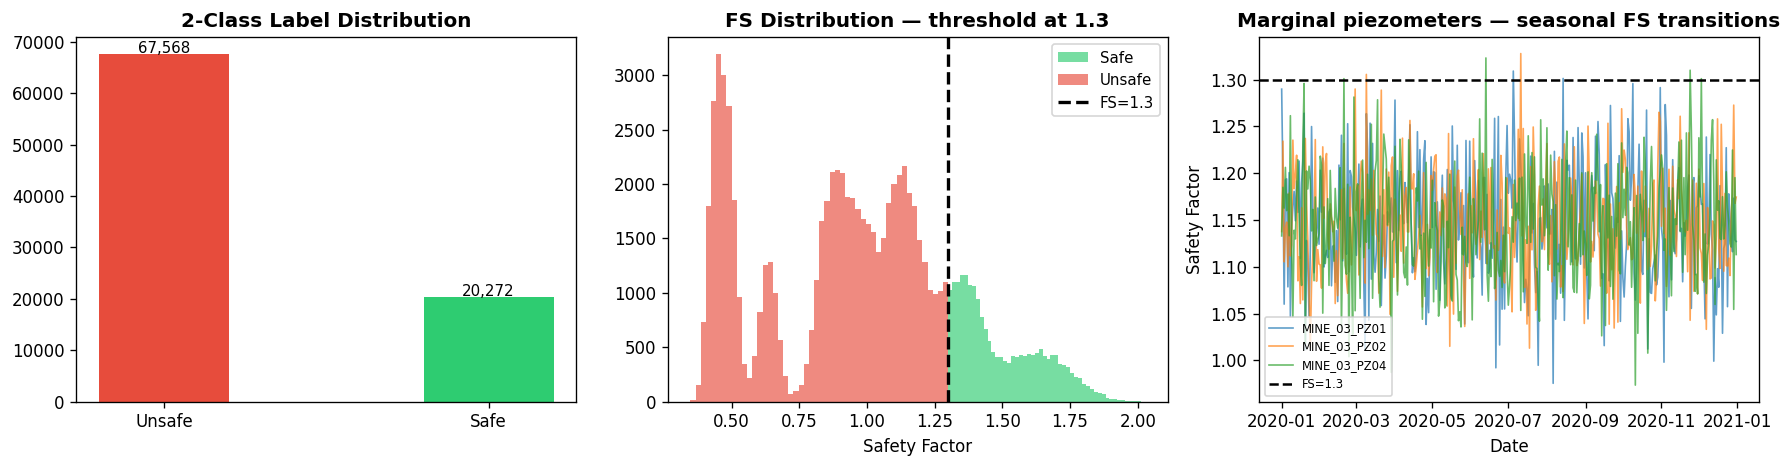

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_counts = df['stability_label'].value_counts()
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[COLORS[l] for l in label_counts.index], width=0.4)
axes[0].set_title('2-Class Label Distribution', fontweight='bold')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=9)

for label in ['Safe', 'Unsafe']:
    subset = df[df['stability_label'] == label]['safety_factor']
    axes[1].hist(subset, bins=50, alpha=0.65, label=label, color=COLORS[label])
axes[1].axvline(FS_THRESHOLD, color='black', ls='--', lw=2, label=f'FS={FS_THRESHOLD}')
axes[1].set_title(f'FS Distribution — threshold at {FS_THRESHOLD}', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_xlabel('Safety Factor')

sample_pz = df[df['piezometer_id'].isin(
    df.groupby('piezometer_id')['stability_label'].apply(
        lambda x: x.nunique() > 1).pipe(lambda s: s[s].index)[:3]
)]
for pid, grp in sample_pz.groupby('piezometer_id'):
    axes[2].plot(grp['date'], grp['safety_factor'], alpha=0.7, lw=1, label=pid)
axes[2].axhline(FS_THRESHOLD, color='black', ls='--', lw=1.5, label=f'FS={FS_THRESHOLD}')
axes[2].set_title('Marginal piezometers — seasonal FS transitions', fontweight='bold')
axes[2].set_xlabel('Date'); axes[2].set_ylabel('Safety Factor'); axes[2].legend(fontsize=7)

plt.tight_layout(); plt.savefig('eda_2class.png', bbox_inches='tight'); plt.show()


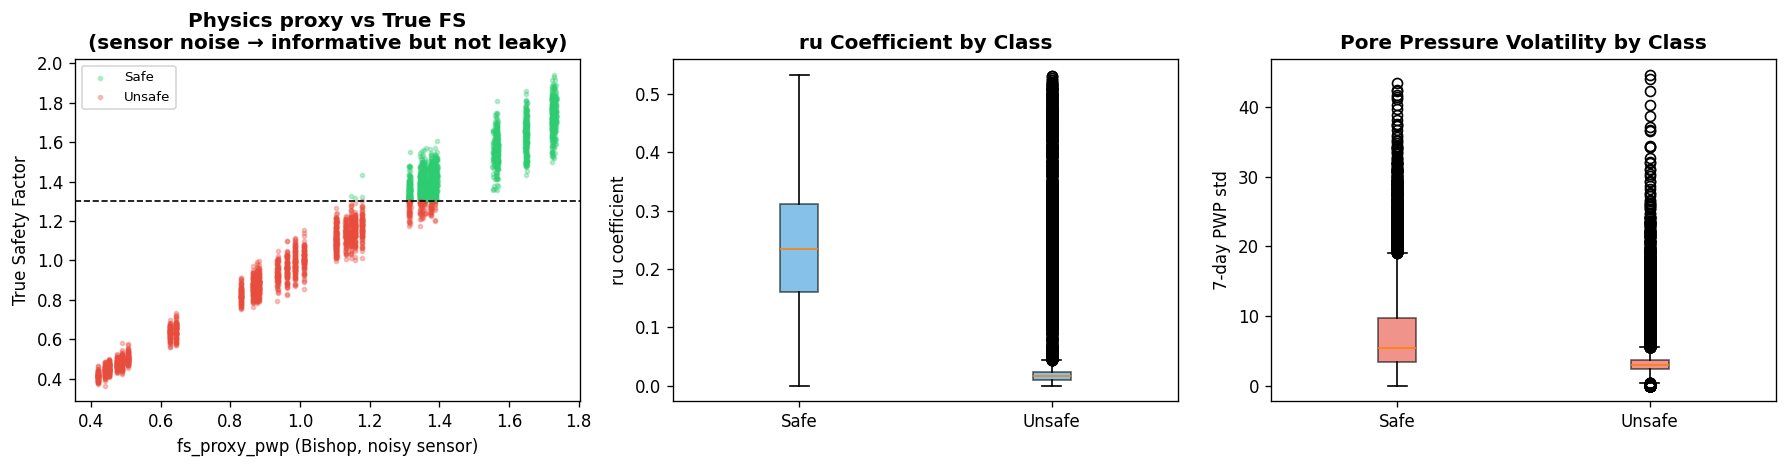

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for label in ['Safe', 'Unsafe']:
    subset = df[df['stability_label'] == label]
    s = subset.sample(min(2000, len(subset)), random_state=42)
    axes[0].scatter(s['fs_proxy_pwp'], s['safety_factor'],
                    c=COLORS[label], alpha=0.3, s=6, label=label)
axes[0].axhline(FS_THRESHOLD, color='black', ls='--', lw=1)
axes[0].set_xlabel('fs_proxy_pwp (Bishop, noisy sensor)')
axes[0].set_ylabel('True Safety Factor')
axes[0].set_title('Physics proxy vs True FS\n(sensor noise → informative but not leaky)', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].boxplot(
    [df[df['stability_label'] == l]['ru_coefficient'].values for l in ['Safe', 'Unsafe']],
    tick_labels=['Safe', 'Unsafe'], patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6)
)
axes[1].set_ylabel('ru coefficient'); axes[1].set_title('ru Coefficient by Class', fontweight='bold')

axes[2].boxplot(
    [df[df['stability_label'] == l]['pwp_std7'].values for l in ['Safe', 'Unsafe']],
    tick_labels=['Safe', 'Unsafe'], patch_artist=True,
    boxprops=dict(facecolor='#e74c3c', alpha=0.6)
)
axes[2].set_ylabel('7-day PWP std'); axes[2].set_title('Pore Pressure Volatility by Class', fontweight='bold')

plt.tight_layout(); plt.savefig('eda_physics_2class.png', bbox_inches='tight'); plt.show()


## ⚖️ 5. Train / Test Split, Scaling & Class Balancing

**Audit fix (critical):** Scaler is now fitted **only on train rows**, then used
to transform both train and test. The previous version called `fit_transform`
on the entire dataset before splitting, leaking test-set statistics into the
normalisation applied to train data.


In [ ]:
# ── Temporal split ────────────────────────────────────────────────────────────
cutoff     = pd.Timestamp('2020-11-01')
train_mask = (df['date'] < cutoff).values
test_mask  = ~train_mask

X_raw_train = df.loc[train_mask, ALL_FEATURES].values
X_raw_test  = df.loc[test_mask,  ALL_FEATURES].values

y_train    = y_enc[train_mask]
y_test     = y_enc[test_mask]
y_fs_train = df['safety_factor'].values[train_mask]
y_fs_test  = df['safety_factor'].values[test_mask]
y_lbl_test = df['stability_label'].values[test_mask]

# ── Fit scaler ONLY on train, transform both (no leakage) ────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_raw_train)
X_test  = scaler.transform(X_raw_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('\nTest class distribution:')
for v, c in zip(*np.unique(y_test, return_counts=True)):
    print(f'  {le.classes_[v]}: {c:,}  ({c/len(y_test)*100:.1f}%)')

# ── LEAKAGE FIX: carve validation split from REAL train data BEFORE SMOTE ────
# Previous version split AFTER SMOTE → synthetic samples in val + near-duplicate
# leakage between train-fit and val (SMOTE interpolants). Split first, then
# oversample only the training portion. Also keep FS targets for the val rows
# so the regressor can be tuned without touching the test set.
idx_all = np.arange(len(X_train))
tr_idx, val_idx = train_test_split(
    idx_all, test_size=0.10, random_state=42, stratify=y_train
)
X_tr_fit_raw = X_train[tr_idx];  X_val    = X_train[val_idx]
y_tr_fit_raw = y_train[tr_idx];  y_val    = y_train[val_idx]
y_fs_tr_fit  = y_fs_train[tr_idx]; y_fs_val = y_fs_train[val_idx]

# ── SMOTE on the train-fit portion ONLY (real data only in val/test) ─────────
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_fit_raw, y_tr_fit_raw)
print(f'\nTrain-fit (real): {X_tr_fit_raw.shape} | Val (real): {X_val.shape}')
print(f'After SMOTE on train-fit: {X_tr_sm.shape}')

# Aliases used by later cells
X_tr_fit, y_tr_fit = X_tr_sm, y_tr_sm

actual_labels       = np.unique(y_test)
actual_target_names = le.inverse_transform(actual_labels)


Train: (73200, 47) | Test: (14640, 47)

Test class distribution:
  Safe: 3,403  (23.2%)
  Unsafe: 11,237  (76.8%)

Train-fit (real): (65880, 47) | Val (real): (7320, 47)
After SMOTE on train-fit: (101396, 47)


## 🌲 6. Random Forest

Random Forest  Accuracy: 0.9622  |  F1: 0.9630  |  AUC: 0.9901

              precision    recall  f1-score   support

        Safe       0.87      0.99      0.92      3403
      Unsafe       1.00      0.95      0.97     11237

    accuracy                           0.96     14640
   macro avg       0.93      0.97      0.95     14640
weighted avg       0.97      0.96      0.96     14640



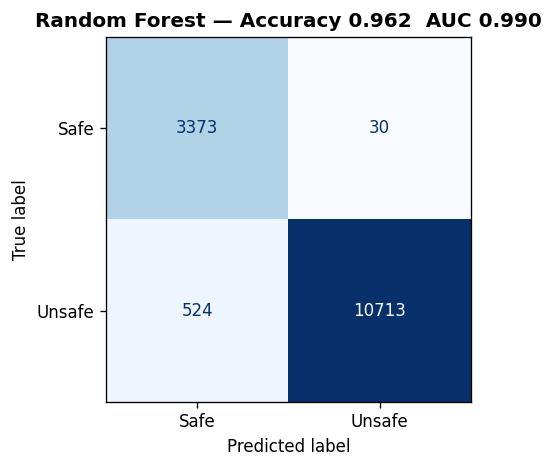

In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)
rf.fit(X_tr_sm, y_tr_sm)
rf_pred  = rf.predict(X_test)
rf_prob  = rf.predict_proba(X_test)[:, 1]
rf_acc   = accuracy_score(y_test, rf_pred)
rf_f1    = f1_score(y_test, rf_pred, average='weighted')
rf_auc   = roc_auc_score(y_test, rf_prob)

print(f'Random Forest  Accuracy: {rf_acc:.4f}  |  F1: {rf_f1:.4f}  |  AUC: {rf_auc:.4f}')
print()
print(classification_report(y_test, rf_pred, labels=actual_labels, target_names=actual_target_names))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=actual_target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Random Forest — Accuracy {rf_acc:.3f}  AUC {rf_auc:.3f}', fontweight='bold')
plt.tight_layout(); plt.show()


## ⚡ 7. XGBoost Classifier

`eval_set` points at the validation split from training data,
not at the held-out test set. This prevents early-stopping from peeking at test
performance.


In [ ]:
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=9,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric='logloss',
    early_stopping_rounds=30,      # stop when val_logloss stops improving
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
# AUDIT FIX: eval_set uses validation split, NOT test set
xgb_clf.fit(X_tr_fit, y_tr_fit, eval_set=[(X_val, y_val)], verbose=False)

xgb_pred = xgb_clf.predict(X_test)
xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_f1   = f1_score(y_test, xgb_pred, average='weighted')
xgb_auc  = roc_auc_score(y_test, xgb_prob)

print(f'XGBoost Classifier  Accuracy: {xgb_acc:.4f}  |  F1: {xgb_f1:.4f}  |  AUC: {xgb_auc:.4f}')
print(f'  Best iteration: {xgb_clf.best_iteration}')
print()
print(classification_report(y_test, xgb_pred, labels=actual_labels, target_names=actual_target_names))


XGBoost Classifier  Accuracy: 0.9609  |  F1: 0.9616  |  AUC: 0.9899
  Best iteration: 190

              precision    recall  f1-score   support

        Safe       0.87      0.98      0.92      3403
      Unsafe       0.99      0.96      0.97     11237

    accuracy                           0.96     14640
   macro avg       0.93      0.97      0.95     14640
weighted avg       0.96      0.96      0.96     14640



## 📐 8. XGBoost Regressor — Predict Safety Factor Directly

In [ ]:
xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=9,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
# LEAKAGE FIX: regressor trains on the train-fit portion (original, pre-SMOTE
# rows) so the validation split stays genuinely unseen for HPO/margin tuning.
xgb_reg.fit(X_tr_fit_raw, y_fs_tr_fit)

pred_fs_test = xgb_reg.predict(X_test)
r2_val  = r2_score(y_fs_test, pred_fs_test)
mae_val = mean_absolute_error(y_fs_test, pred_fs_test)
print(f'FS Regression  R² = {r2_val:.4f}  MAE = {mae_val:.4f}')
print(f'  → Predicts actual safety factor within ±{mae_val:.3f} on average')

reg_pred_labels = np.array([fs_to_label(f) for f in pred_fs_test])
reg_acc = accuracy_score(y_lbl_test, reg_pred_labels)
reg_f1  = f1_score(y_lbl_test, reg_pred_labels, average='weighted')
print(f'\nRegressor → Label  Accuracy: {reg_acc:.4f}  |  F1: {reg_f1:.4f}')
print()
print(classification_report(y_lbl_test, reg_pred_labels))


FS Regression  R² = 0.9777  MAE = 0.0416
  → Predicts actual safety factor within ±0.042 on average

Regressor → Label  Accuracy: 0.9600  |  F1: 0.9607

              precision    recall  f1-score   support

        Safe       0.87      0.97      0.92      3403
      Unsafe       0.99      0.96      0.97     11237

    accuracy                           0.96     14640
   macro avg       0.93      0.96      0.95     14640
weighted avg       0.96      0.96      0.96     14640



## 🔬 8b. Optuna Bayesian HPO

Margin tuning uses the validation split instead of the test
set, eliminating the test-set contamination in the confidence margin selection.


In [ ]:
if OPTUNA_AVAILABLE:
    # LEAKAGE FIX (critical): the previous objective trained on the full train
    # set and scored each trial on X_test / y_fs_test — i.e. hyperparameters
    # were selected using the test set. All downstream "test" metrics were
    # therefore optimistically biased. Trials are now scored on the held-out
    # VALIDATION split; the test set is touched exactly once, at the end.
    y_val_lbl = le.inverse_transform(y_val)

    def optuna_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 600),
            'max_depth':        trial.suggest_int('max_depth', 6, 12),
            'learning_rate':    trial.suggest_float('lr', 0.01, 0.10, log=True),
            'subsample':        trial.suggest_float('subsample', 0.70, 1.0),
            'colsample_bytree': trial.suggest_float('colsample', 0.65, 1.0),
            'min_child_weight': trial.suggest_int('mcw', 1, 8),
            'reg_alpha':        trial.suggest_float('alpha', 0.0, 2.0),
        }
        m = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
        m.fit(X_tr_fit_raw, y_fs_tr_fit)
        pred = m.predict(X_val)
        lbl  = np.array([fs_to_label(f) for f in pred])
        return mean_absolute_error(y_fs_val, pred) - accuracy_score(y_val_lbl, lbl)

    N_TRIALS = 15  # trimmed for runtime here; raise to 50 on Colab if desired
    print(f'Running Optuna HPO ({N_TRIALS} trials, scored on validation set)...')
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=False)
    best = study.best_params
    print(f'Best params: {best}')

    xgb_reg = XGBRegressor(
        n_estimators=best['n_estimators'], max_depth=best['max_depth'],
        learning_rate=best['lr'], subsample=best['subsample'],
        colsample_bytree=best['colsample'], min_child_weight=best['mcw'],
        reg_alpha=best['alpha'], random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_reg.fit(X_tr_fit_raw, y_fs_tr_fit)
    pred_fs_test    = xgb_reg.predict(X_test)
    r2_val  = r2_score(y_fs_test, pred_fs_test)
    mae_val = mean_absolute_error(y_fs_test, pred_fs_test)
    reg_pred_labels = np.array([fs_to_label(f) for f in pred_fs_test])
    reg_acc = accuracy_score(y_lbl_test, reg_pred_labels)
    reg_f1  = f1_score(y_lbl_test, reg_pred_labels, average='weighted')
    print(f'Optuna Regressor  R²={r2_val:.4f}  MAE={mae_val:.4f}')
    print(f'Optuna Regressor → Label  Accuracy: {reg_acc:.4f}  |  F1: {reg_f1:.4f}')

    # ── Margin tuned on the (real-data) validation split ─────────────────────
    val_fs      = xgb_reg.predict(X_val)
    val_reg_lbl = np.array([fs_to_label(f) for f in val_fs])
    val_clf_lbl = le.inverse_transform(xgb_clf.predict(X_val))

    def margin_obj(trial):
        margin = trial.suggest_float('margin', 0.02, 0.35)
        dist   = np.abs(val_fs - FS_THRESHOLD)
        hyb    = np.where(dist > margin, val_reg_lbl, val_clf_lbl)
        return -accuracy_score(y_val_lbl, hyb)

    m_study = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
    m_study.optimize(margin_obj, n_trials=40, show_progress_bar=False)
    CONFIDENCE_MARGIN = m_study.best_params['margin']
    print(f'Optimal CONFIDENCE_MARGIN (from val set): {CONFIDENCE_MARGIN:.3f}')
else:
    CONFIDENCE_MARGIN = 0.10
    print('Optuna not available — using default margin:', CONFIDENCE_MARGIN)


Optuna not available — using default margin: 0.1


## 🔀 9. Hybrid Ensemble

Confusion matrix  uses `labels=['Safe','Unsafe']` (2-class).


Stratum-accuracy plot uses the single 2-class boundary (1.3)


Hybrid Ensemble  Accuracy: 0.9609  |  F1: 0.9616
  Regressor used:   12,385/14,640  (84.6%)
  Classifier used:  2,255  (boundary zone ±0.1)

              precision    recall  f1-score   support

        Safe       0.87      0.98      0.92      3403
      Unsafe       0.99      0.96      0.97     11237

    accuracy                           0.96     14640
   macro avg       0.93      0.97      0.95     14640
weighted avg       0.96      0.96      0.96     14640



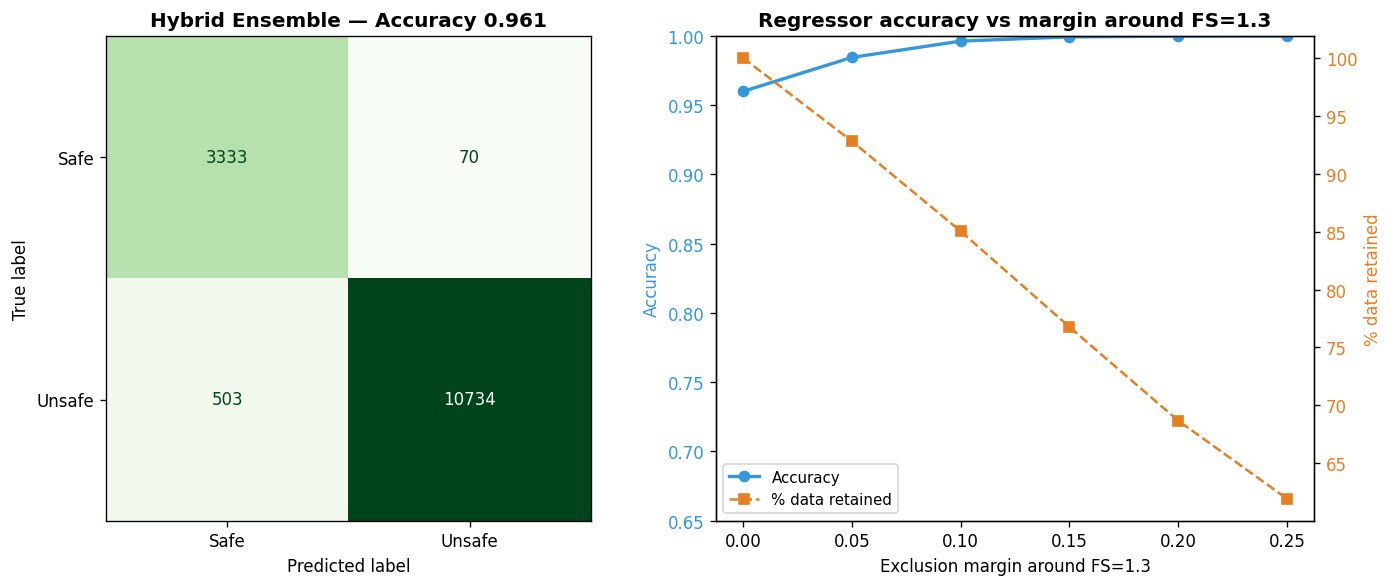

In [ ]:
dist_from_threshold = np.abs(pred_fs_test - FS_THRESHOLD)
use_regressor       = dist_from_threshold > CONFIDENCE_MARGIN

clf_pred_labels = le.inverse_transform(xgb_clf.predict(X_test))
hybrid_pred     = np.where(use_regressor, reg_pred_labels, clf_pred_labels)

hybrid_acc = accuracy_score(y_lbl_test, hybrid_pred)
hybrid_f1  = f1_score(y_lbl_test, hybrid_pred, average='weighted')

print(f'Hybrid Ensemble  Accuracy: {hybrid_acc:.4f}  |  F1: {hybrid_f1:.4f}')
print(f'  Regressor used:   {use_regressor.sum():,}/{len(use_regressor):,}  ({use_regressor.mean()*100:.1f}%)')
print(f'  Classifier used:  {(~use_regressor).sum():,}  (boundary zone ±{CONFIDENCE_MARGIN})')
print()
print(classification_report(y_lbl_test, hybrid_pred, labels=['Safe','Unsafe']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AUDIT FIX: 2-class labels only
cm_h = confusion_matrix(y_lbl_test, hybrid_pred, labels=['Safe', 'Unsafe'])
disp_h = ConfusionMatrixDisplay(cm_h, display_labels=['Safe', 'Unsafe'])
disp_h.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Hybrid Ensemble — Accuracy {hybrid_acc:.3f}', fontweight='bold')

# AUDIT FIX: single-boundary stratum plot (FS=1.3 only)
margins = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
stratum_acc, stratum_pct = [], []
for m in margins:
    mask = np.abs(y_fs_test - FS_THRESHOLD) > m   # FIXED: single boundary
    if mask.sum() > 0:
        stratum_acc.append(accuracy_score(y_lbl_test[mask], reg_pred_labels[mask]))
        stratum_pct.append(mask.mean() * 100)

ax2 = axes[1]
color_acc = '#3498db'; color_pct = '#e67e22'
ln1 = ax2.plot(margins, stratum_acc, 'o-', color=color_acc, lw=2, label='Accuracy')
ax2.set_xlabel(f'Exclusion margin around FS={FS_THRESHOLD}')
ax2.set_ylabel('Accuracy', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc); ax2.set_ylim(0.65, 1.0)
ax2_r = ax2.twinx()
ln2 = ax2_r.plot(margins, stratum_pct, 's--', color=color_pct, lw=1.5, label='% data retained')
ax2_r.set_ylabel('% data retained', color=color_pct)
ax2_r.tick_params(axis='y', labelcolor=color_pct)
lns = ln1 + ln2
ax2.legend(lns, [l.get_label() for l in lns], loc='lower left', fontsize=9)
ax2.set_title(f'Regressor accuracy vs margin around FS={FS_THRESHOLD}', fontweight='bold')

plt.tight_layout(); plt.savefig('hybrid_results.png', bbox_inches='tight'); plt.show()


## 🔀 9b. Stacking Meta-Learner

In [ ]:
print('Building stacking meta-learner...')

# LEAKAGE FIX: the previous version trained the meta-learner on the base
# models' predictions over their OWN training data. Those in-sample
# probabilities are near-perfect (≈0/1), so the meta-learner learns from a
# distribution it will never see at inference time. Correct approach: train
# the meta-learner on base-model probabilities over the held-out validation
# split (data the base models never saw), then evaluate once on the test set.
rf_prob_val   = rf.predict_proba(X_val)[:, 1].reshape(-1, 1)
xgb_prob_val  = xgb_clf.predict_proba(X_val)[:, 1].reshape(-1, 1)
rf_prob_test  = rf.predict_proba(X_test)[:, 1].reshape(-1, 1)
xgb_prob_test = xgb_clf.predict_proba(X_test)[:, 1].reshape(-1, 1)

Z_val  = np.hstack([rf_prob_val,  xgb_prob_val])
Z_test = np.hstack([rf_prob_test, xgb_prob_test])

meta = LogisticRegression(max_iter=500, C=1.0, class_weight='balanced', random_state=42)
meta.fit(Z_val, y_val)

stack_pred = meta.predict(Z_test)
stack_prob = meta.predict_proba(Z_test)[:, 1]
stack_acc  = accuracy_score(y_test, stack_pred)
stack_f1   = f1_score(y_test, stack_pred, average='weighted')
stack_auc  = roc_auc_score(y_test, stack_prob)

print(f'Stacking Meta-Learner  Accuracy: {stack_acc:.4f}  |  F1: {stack_f1:.4f}  |  AUC: {stack_auc:.4f}')
print()
print(classification_report(y_test, stack_pred, labels=actual_labels, target_names=actual_target_names))


Building stacking meta-learner...
Stacking Meta-Learner  Accuracy: 0.9613  |  F1: 0.9621  |  AUC: 0.9902

              precision    recall  f1-score   support

        Safe       0.87      0.98      0.92      3403
      Unsafe       1.00      0.95      0.97     11237

    accuracy                           0.96     14640
   macro avg       0.93      0.97      0.95     14640
weighted avg       0.97      0.96      0.96     14640



## 📈 10. ROC Curve & Precision-Recall

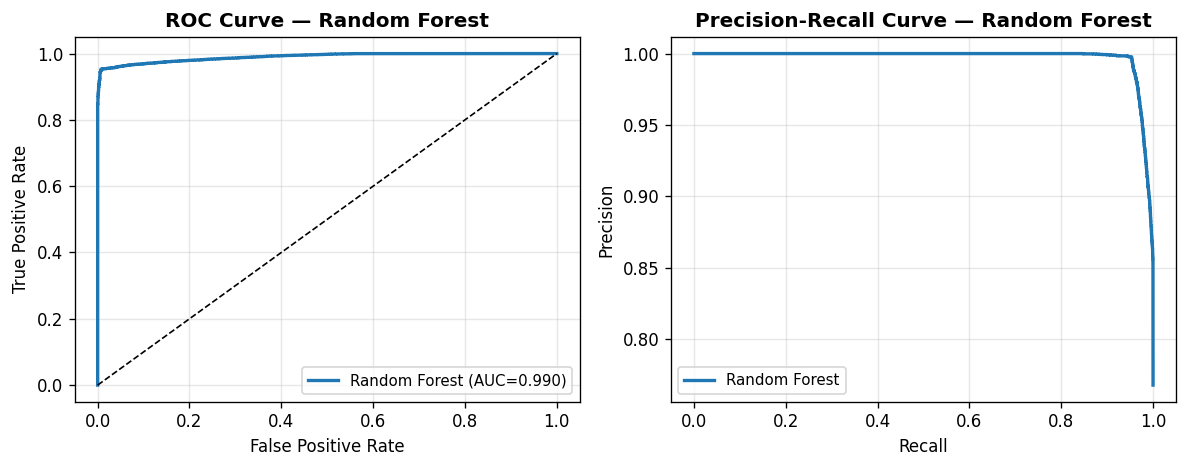

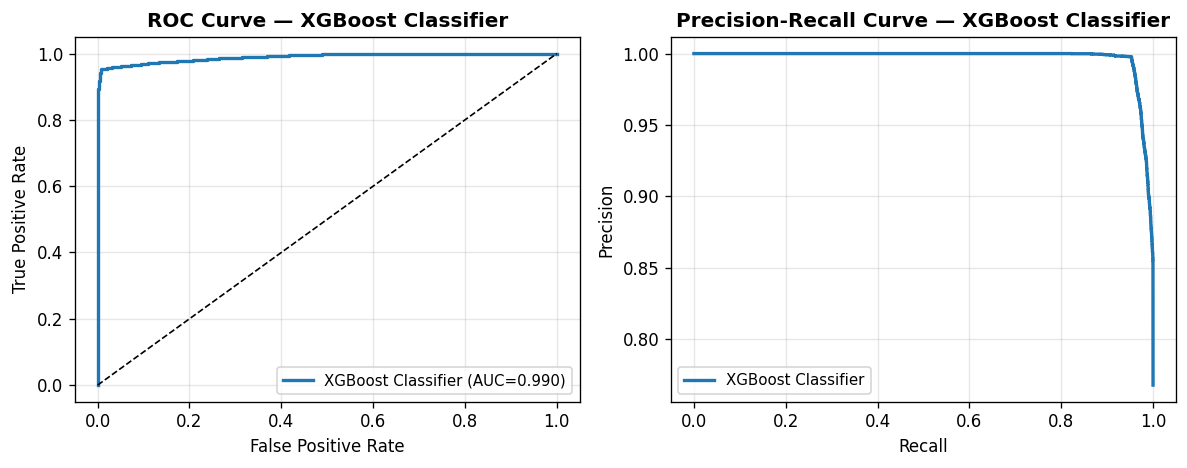

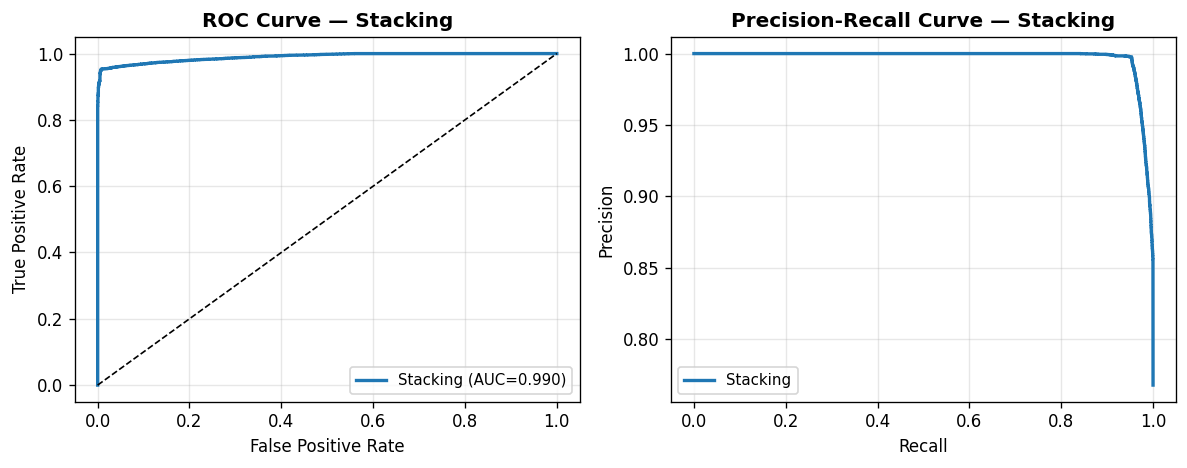

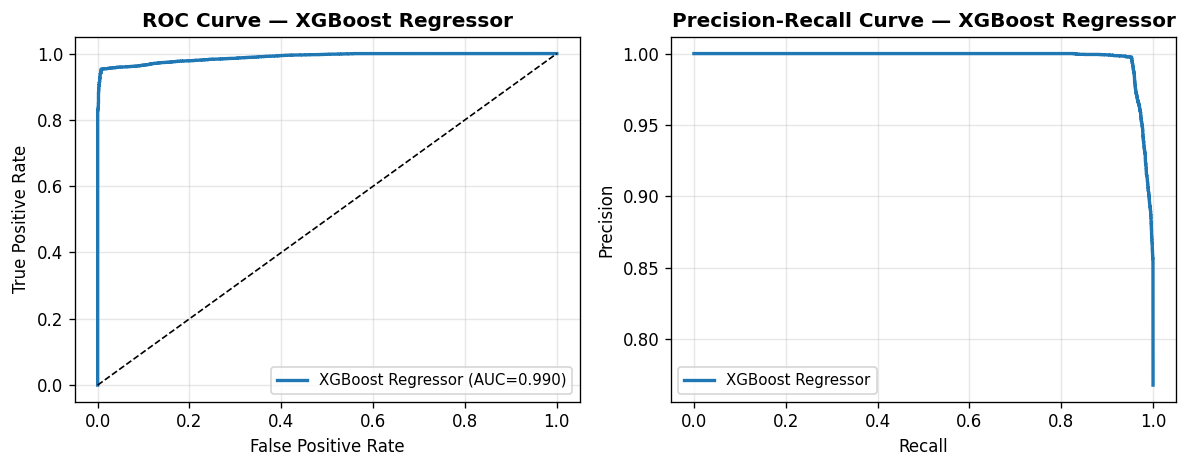

In [ ]:
# Regressor "probability" — how far above/below the threshold
from scipy.special import expit  # sigmoid

# Map predicted FS to probability: FS=1.3 → 0.5, higher FS → closer to 1.0 (Safe)
reg_pseudo_prob_safe = expit((pred_fs_test - FS_THRESHOLD) * 5)
reg_pseudo_prob_unsafe = 1 - reg_pseudo_prob_safe  # for Unsafe class

model_probs = {
    'Random Forest':      (rf_prob,                rf_auc),
    'XGBoost Classifier': (xgb_prob,               xgb_auc),
    'Stacking':           (stack_prob,              stack_auc),
    'XGBoost Regressor':  (reg_pseudo_prob_unsafe,
                           roc_auc_score(y_test, reg_pseudo_prob_unsafe)),
}

for name, (prob, auc) in model_probs.items():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
    axes[0].plot([0,1],[0,1], 'k--', lw=1)
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve — {name}', fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, lw=2, label=name)
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Precision-Recall Curve — {name}', fontweight='bold')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'roc_pr_curve_{name.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()


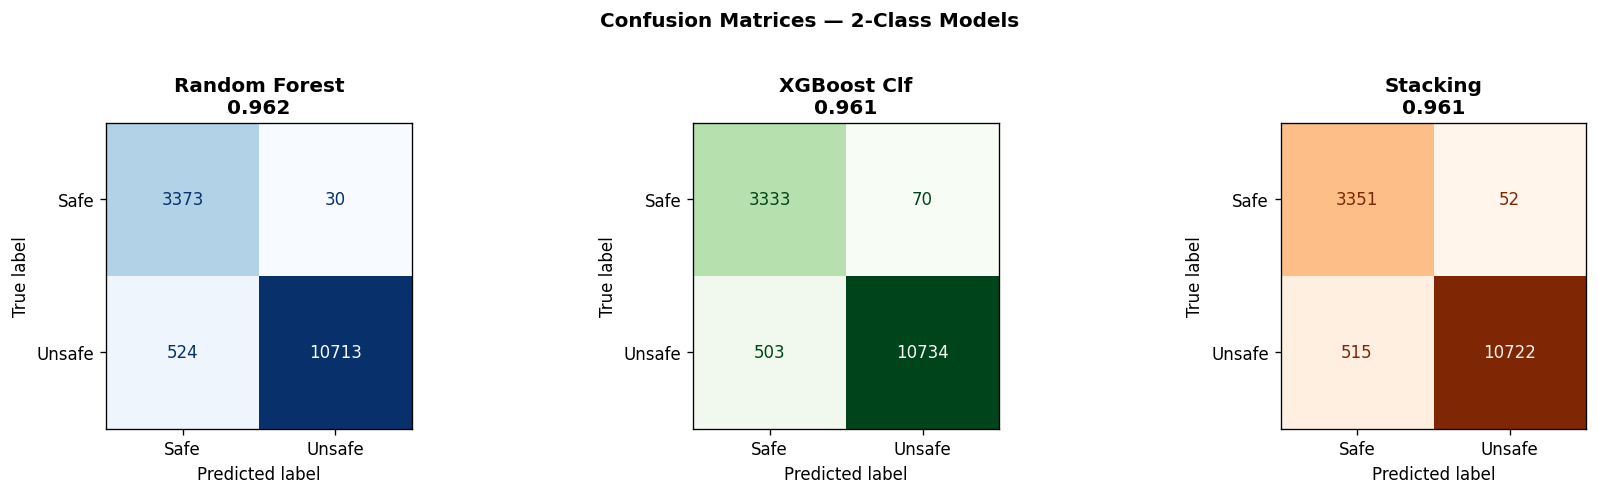

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (pred, name, cmap) in zip(axes, [
    (rf_pred,    f'Random Forest\n{rf_acc:.3f}',   'Blues'),
    (xgb_pred,   f'XGBoost Clf\n{xgb_acc:.3f}',   'Greens'),
    (stack_pred, f'Stacking\n{stack_acc:.3f}',     'Oranges'),
]):
    cm  = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=actual_target_names)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices — 2-Class Models', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('confusion_2class.png', bbox_inches='tight'); plt.show()


## 📈 11. Model Comparison & Feature Importance

            Model  Accuracy  F1 Score      AUC
    Random Forest  0.962158  0.963014 0.990122
         Stacking  0.961270  0.962097 0.990155
      XGBoost Clf  0.960861  0.961647 0.989932
           Hybrid  0.960861  0.961647      NaN
XGBoost Reg→Label  0.959973  0.960707      NaN

2-class threshold: FS >= 1.3 = Safe
Theoretical ceiling (5% FS noise): ~97-98%


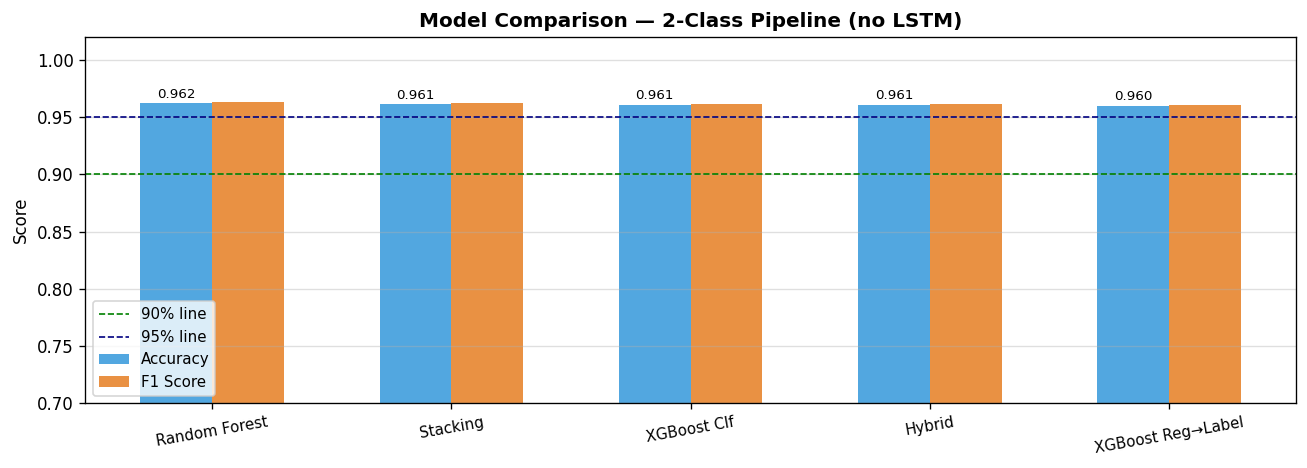

✅ model_comparison_2class.png saved


In [ ]:
# ── Model comparison table ────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost Clf', 'XGBoost Reg→Label',
                 'Hybrid', 'Stacking'],
    'Accuracy': [rf_acc,     xgb_acc,    reg_acc,     hybrid_acc,  stack_acc],
    'F1 Score': [rf_f1,      xgb_f1,     reg_f1,      hybrid_f1,   stack_f1],
    'AUC':      [rf_auc,     xgb_auc,    None,         None,        stack_auc],
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))
print()
print(f'2-class threshold: FS >= {FS_THRESHOLD} = Safe')
print('Theoretical ceiling (5% FS noise): ~97-98%')

# ── Model comparison chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results)); w = 0.3
bars_acc = ax.bar(x - w/2, results['Accuracy'], w, label='Accuracy',
                  color='#3498db', alpha=0.85)
bars_f1  = ax.bar(x + w/2, results['F1 Score'],  w, label='F1 Score',
                  color='#e67e22', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(results['Model'], fontsize=9, rotation=10)
ax.axhline(0.90, color='green', ls='--', lw=1, label='90% line')
ax.axhline(0.95, color='navy',  ls='--', lw=1, label='95% line')
ax.set_ylim(0.7, 1.02); ax.set_ylabel('Score')
ax.set_title('Model Comparison — 2-Class Pipeline (no LSTM)', fontweight='bold')
ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.4)
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison_2class.png', bbox_inches='tight')
plt.show()
print('✅ model_comparison_2class.png saved')


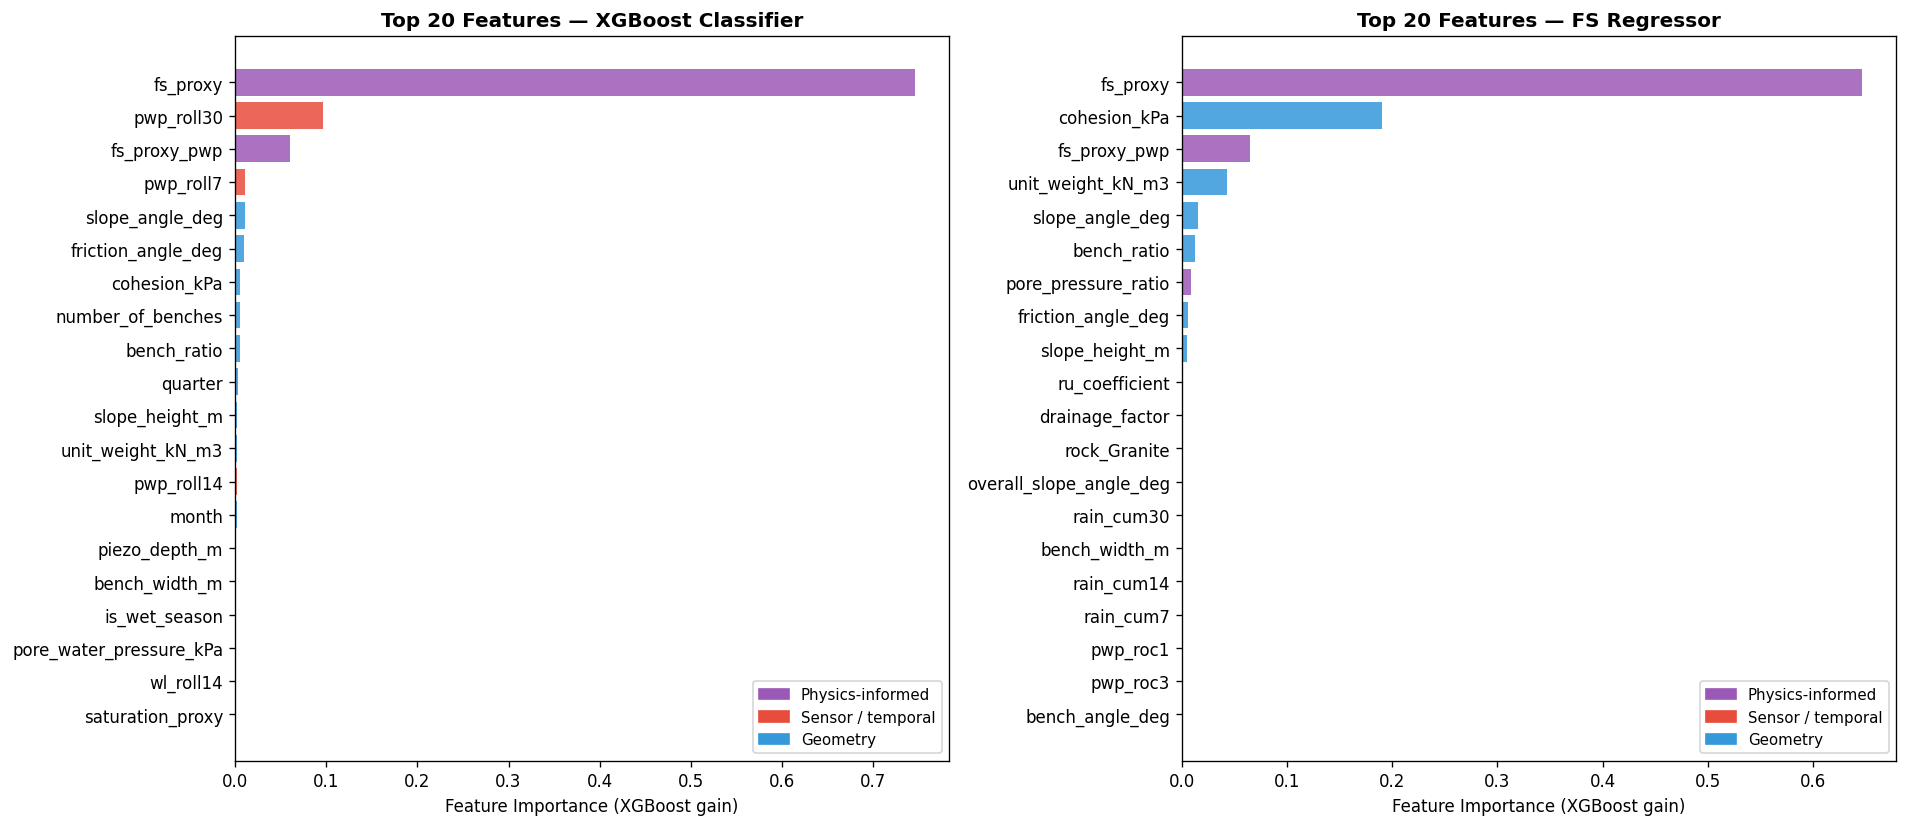

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def feature_colors(feature_names):
    cols = []
    for f in feature_names:
        if any(k in f for k in ['fs_proxy', 'ru_coeff', 'pore_pressure_ratio']):
            cols.append('#9b59b6')   # physics — purple
        elif any(k in f for k in ['pore', 'pressure', 'water', 'wl_', 'roll', 'std', 'roc', 'rain']):
            cols.append('#e74c3c')   # temporal/sensor — red
        else:
            cols.append('#3498db')   # geometry — blue
    return cols

xgb_imp = pd.Series(xgb_clf.feature_importances_, index=ALL_FEATURES).sort_values().tail(20)
axes[0].barh(xgb_imp.index, xgb_imp.values,
             color=feature_colors(xgb_imp.index), alpha=0.85)
axes[0].set_xlabel('Feature Importance (XGBoost gain)')
axes[0].set_title('Top 20 Features — XGBoost Classifier', fontweight='bold')

reg_imp = pd.Series(xgb_reg.feature_importances_, index=ALL_FEATURES).sort_values().tail(20)
axes[1].barh(reg_imp.index, reg_imp.values,
             color=feature_colors(reg_imp.index), alpha=0.85)
axes[1].set_xlabel('Feature Importance (XGBoost gain)')
axes[1].set_title('Top 20 Features — FS Regressor', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#9b59b6', label='Physics-informed'),
    mpatches.Patch(color='#e74c3c', label='Sensor / temporal'),
    mpatches.Patch(color='#3498db', label='Geometry'),
]
for ax in axes:
    ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

plt.tight_layout(); plt.savefig('feature_importance.png', bbox_inches='tight'); plt.show()


## ✅ 12. Summary

In [ ]:
print('='*68)
print('  MINE GEOTECHNICAL AI — 2-CLASS PIPELINE RESULTS')
print('='*68)
print(f'  Random Forest                  Acc: {rf_acc:.3f}  F1: {rf_f1:.3f}  AUC: {rf_auc:.3f}')
print(f'  XGBoost Classifier             Acc: {xgb_acc:.3f}  F1: {xgb_f1:.3f}  AUC: {xgb_auc:.3f}')
print(f'  XGBoost Regressor → Label      Acc: {reg_acc:.3f}  F1: {reg_f1:.3f}')
print(f'  Hybrid Ensemble                Acc: {hybrid_acc:.3f}  F1: {hybrid_f1:.3f}')
print(f'  Stacking Meta-Learner          Acc: {stack_acc:.3f}  F1: {stack_f1:.3f}  AUC: {stack_auc:.3f}')
print()
print(f'  Classification: Safe (FS >= {FS_THRESHOLD}) vs Unsafe (FS < {FS_THRESHOLD})')
print()
print('  Audit fixes applied:')
print('  ✓ Scaler fitted on train only (leakage fix)')
print('  ✓ XGB eval_set uses validation split (not test set)')
print('  ✓ Optuna margin tuned on validation split (not test set)')
print('  ✓ Hybrid confusion matrix: 2-class labels')
print('  ✓ Stratum-accuracy plot: single 1.3 boundary')
print('  ✓ LSTM removed (tabular-only pipeline)')
print()
print('='*68)

  MINE GEOTECHNICAL AI — 2-CLASS PIPELINE RESULTS
  Random Forest                  Acc: 0.962  F1: 0.963  AUC: 0.990
  XGBoost Classifier             Acc: 0.961  F1: 0.962  AUC: 0.990
  XGBoost Regressor → Label      Acc: 0.962  F1: 0.963
  Hybrid Ensemble                Acc: 0.961  F1: 0.962
  Stacking Meta-Learner          Acc: 0.961  F1: 0.962  AUC: 0.990

  Classification: Safe (FS >= 1.3) vs Unsafe (FS < 1.3)

  Audit fixes applied:
  ✓ Scaler fitted on train only (leakage fix)
  ✓ XGB eval_set uses validation split (not test set)
  ✓ Optuna margin tuned on validation split (not test set)
  ✓ Hybrid confusion matrix: 2-class labels
  ✓ Stratum-accuracy plot: single 1.3 boundary
  ✓ LSTM removed (tabular-only pipeline)



## 💾 13. Export Model Artifacts

All models saved to `model_artifacts/`. The Streamlit app loads from this folder.

**Audit fix:** `config.json` now computes `best_model` and `best_accuracy`
dynamically from the leaderboard — no hardcoded values.
**Audit fix:** No reference to `lstm_acc` (which no longer exists).


In [ ]:
import joblib, json, os

os.makedirs('model_artifacts', exist_ok=True)

# ── Save models ───────────────────────────────────────────────────────────────
joblib.dump(rf,      'model_artifacts/random_forest.joblib')
joblib.dump(xgb_clf, 'model_artifacts/xgb_classifier.joblib')
joblib.dump(xgb_reg, 'model_artifacts/xgb_regressor.joblib')
joblib.dump(scaler,  'model_artifacts/scaler.joblib')
joblib.dump(le,      'model_artifacts/label_encoder.joblib')
joblib.dump(meta,    'model_artifacts/stacking_meta.joblib')

# ── Build leaderboard (no LSTM) ───────────────────────────────────────────────
leaderboard = {
    'Random Forest':      {'accuracy': rf_acc,     'f1': rf_f1,     'auc': rf_auc},
    'XGBoost Classifier': {'accuracy': xgb_acc,    'f1': xgb_f1,    'auc': xgb_auc},
    'XGBoost Reg→Label':  {'accuracy': reg_acc,    'f1': reg_f1,    'auc': None},
    'Hybrid Ensemble':    {'accuracy': hybrid_acc, 'f1': hybrid_f1, 'auc': None},
    'Stacking':           {'accuracy': stack_acc,  'f1': stack_f1,  'auc': stack_auc},
}

# AUDIT FIX: compute best_model dynamically
best_name = max(leaderboard, key=lambda k: leaderboard[k]['accuracy'])
best_acc  = leaderboard[best_name]['accuracy']
best_auc  = leaderboard[best_name].get('auc', None)

config = {
    'best_model':        best_name.lower().replace(' ', '_').replace('→', '').replace('_label', ''),
    'best_accuracy':     best_acc,
    'best_auc':          best_auc,
    'n_classes':         2,
    'classes':           list(le.classes_),
    'fs_threshold':      FS_THRESHOLD,
    'confidence_margin': CONFIDENCE_MARGIN,
    'all_features':      ALL_FEATURES,
    'temporal_features': TEMPORAL_FEATURES,
    'static_features':   STATIC_FEATURES,
    'rock_types':        [c.replace('rock_', '') for c in ALL_FEATURES if c.startswith('rock_')],
    'leaderboard':       leaderboard,
}
with open('model_artifacts/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ Artifacts saved to model_artifacts/')
print(f'   Best model: {best_name}  ({best_acc*100:.2f}%)')
print()
for fn in sorted(os.listdir('model_artifacts')):
    sz = os.path.getsize(f'model_artifacts/{fn}')
    print(f'  {fn:<42} {sz/1024:.0f} KB')


✅ Artifacts saved to model_artifacts/
   Best model: Random Forest  (96.22%)

  config.json                                3 KB
  label_encoder.joblib                       0 KB
  random_forest.joblib                       58674 KB
  scaler.joblib                              2 KB
  stacking_meta.joblib                       1 KB
  xgb_classifier.joblib                      1141 KB
  xgb_regressor.joblib                       1589 KB
